#Classificação com QDA, LDA e SVM

## Objetivo e justificativa

Imagine que um banco quer definir seus clientes em bons pagadores e mals pagadores. Independentemente da métrica, suponha que o banco queira também, disponibilizar mais crédito que o números de bons pagadores, como o banco distinguiria os mals pagadores para fazer a disponibilização de crédito. Por isso, vamos aplicar nossos modelos classificadores em outra variável que seja mais coerente.


**Variável-alvo:** `NumberOfDependents` — variável inteira que indica o número de dependentes do requerente de crédito.

**Justificativa da escolha do alvo:** Em relação à variável `SeriousDlqin2yrs`, no conjunto de teste ela apresenta um comportamento probabilístico. No entanto, a natureza dos classificadores QDA, LDA  e SVM são puramente categórica — ou seja, eles não atribuem uma probabilidade contínua a cada decisão. Por isso, optamos por utilizar esses modelos para prever `NumberOfDependents`, criando uma nova coluna que a representa em faixas.



## Bibliotecas

In [1]:
#Biblioteca usuais
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# Importa classificadores baseados em análise discriminante (linear e quadrática)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Importa funções para calcular métricas de desempenho (acurácia e matriz de confusão)
from sklearn.metrics import accuracy_score, confusion_matrix

# Ferramentas para dividir dados em treino/teste e buscar melhores hiperparâmetros (GridSearch)
from sklearn.model_selection import train_test_split, GridSearchCV

# Criação de pipelines que encadeiam etapas de pré-processamento e modelagem
from sklearn.pipeline import make_pipeline

# Ferramenta de padronização de dados (transforma features para média 0 e desvio 1)
from sklearn.preprocessing import StandardScaler

# Importa o classificador SVM (máquina de vetores de suporte)
from sklearn.svm import SVC

from sklearn.model_selection import KFold

# Outras métricas de avaliação: acurácia, matriz de confusão, relatório de classificação
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score
)

## Preparação dos dados

In [3]:
#Carregamento dos dados

treino = pd.read_csv('../final_data/treino.csv') # dados de treino
teste = pd.read_csv('../final_data/teste.csv') # dados de teste

In [4]:
#colunas originais do banco de dados

treino.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [5]:
#listas auxiliares
class_lista_test = []
class_lista_treino = []

#Preechimento das listas auxiliares, com variáveis categóricas
for i in range(len(treino)):
  if treino.loc[i, 'NumberOfDependents'] == 0:
    class_lista_treino.append("0 dependents")
  elif treino.loc[i, 'NumberOfDependents'] == 1:
    class_lista_treino.append("1 dependent")
  elif treino.loc[i, 'NumberOfDependents'] == 2:
    class_lista_treino.append("2 ddependents")
  else:
    class_lista_treino.append("3+ dependents")

for i in range(len((teste))):
  if teste.loc[i, 'NumberOfDependents'] == 0:
    class_lista_test.append("0 dependents")
  elif teste.loc[i, 'NumberOfDependents'] == 1:
    class_lista_test.append("1 dependent")
  elif teste.loc[i, 'NumberOfDependents'] == 2:
    class_lista_test.append("2 ddependents")
  else:
    class_lista_test.append("3+ dependents")

#Associação das listas auxiliares a nosso conjunto de dados de treino e teste
treino['NumberOfDependents_adapted'] = class_lista_treino
teste['NumberOfDependents_adapted'] = class_lista_test

A nova coluna `NumberOfDependents_adapted` será a coluna que iremos usar para treinar os modelos. Ela tem um comportamento categórico como era almejado.

Abaixo, separamos as colunas que vamos utilizar para treino e teste. Após isso, reescalamos nossas variáveis para evitar erros numéricos posteriores.

Foi removido a coluna `SeriousDlqin2yrs` devido a sua mudança de comportamento entre os dados de teste e de treino.

In [6]:

X_train = treino.drop(['SeriousDlqin2yrs', 'NumberOfDependents_adapted', 'NumberOfDependents'], axis=1)
y_train = treino['NumberOfDependents_adapted']

X_test = teste.drop(['SeriousDlqin2yrs', 'NumberOfDependents_adapted', 'NumberOfDependents'], axis=1)
y_test = teste['NumberOfDependents_adapted']

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Abaixo, usamos treinamos 4 modelos: LDA, QDA, SVM(kernel linear) e SVM(Kernel Gaussiano)

# LDA

Abaixo temos a aplicação do modelo LDA.

In [7]:
#treino
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

#print das acurácias
print("Acurácia do Treino:", accuracy_score(y_train, lda.predict(X_train)))
print("Acurácia do Teste:", accuracy_score(y_test, lda.predict(X_test)))

Acurácia do Treino: 0.5931090665133218
Acurácia do Teste: 0.5909261001041698


Abaixo temos a vizualização de acertos e erros dos componentes do LDA que mais discriminam os dados.

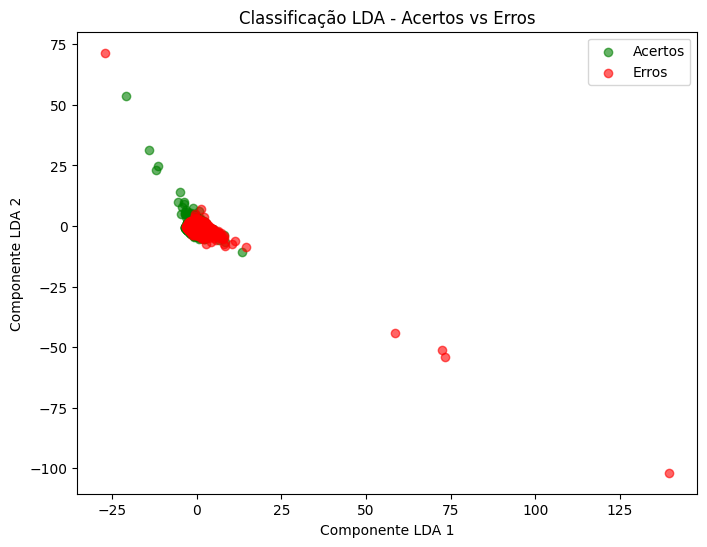

In [8]:
acertos = lda.predict(X_test) == y_test
erros = ~acertos


X_lda = lda.transform(X_test)

# Plotando
plt.figure(figsize=(8,6))
plt.scatter(X_lda[acertos, 0], X_lda[acertos, 1], color='green', label='Acertos', alpha=0.6)
plt.scatter(X_lda[erros, 0], X_lda[erros, 1], color='red', label='Erros', alpha=0.6)
plt.title('Classificação LDA - Acertos vs Erros')
plt.xlabel('Componente LDA 1')
plt.ylabel('Componente LDA 2')
plt.legend()
plt.show()

In [24]:
print('insights do fit de LDA')
print(classification_report(y_test, lda.predict(X_test)))

insights do fit de LDA
               precision    recall  f1-score   support

 0 dependents       0.59      0.99      0.74     58618
  1 dependent       0.22      0.00      0.00     17618
2 ddependents       0.20      0.01      0.02     13298
3+ dependents       0.18      0.00      0.00      9343

     accuracy                           0.59     98877
    macro avg       0.30      0.25      0.19     98877
 weighted avg       0.43      0.59      0.44     98877



# QDA

Escolha do hiperparâmetro `reg_param`.
Esse hiperparâmetro controla um ruído adicionado na tabela de correlação. Pois pode acontecer de algumas entradas da matriz de correlação serem muitos pequenas, o que pode acarretar em futuros erros numéricos.

In [10]:
k = 0
right_param = 0

for i in range(1, 1001):
  qda = QuadraticDiscriminantAnalysis(reg_param = i/1000)
  qda.fit(X_train, y_train)
  if accuracy_score(y_train, qda.predict(X_train)) > k:
    k = accuracy_score(y_train, qda.predict(X_train))
    right_param = i/1000


print("Best score:", k)
print("Best param:", right_param)

Best score: 0.5924792573728744
Best param: 0.999


Abaixo temos a aplicação do modelo QDA com o hiperparâmetro calculado no código anterior.

In [11]:
qda = QuadraticDiscriminantAnalysis(reg_param = right_param)
qda.fit(X_train, y_train)

,priors,None
,reg_param,0.999
,store_covariance,False
,tol,0.0001


In [25]:
#print das acurácias
print("Acurácia do Treino:", accuracy_score(y_train, qda.predict(X_train)))
print("Acurácia do Teste:", accuracy_score(y_test, qda.predict(X_test)))

print('insights do fit de QDA')
print(classification_report(y_test, qda.predict(X_test)))

Acurácia do Treino: 0.5924792573728744
Acurácia do Teste: 0.5904001941806487
insights do fit de QDA
               precision    recall  f1-score   support

 0 dependents       0.59      0.99      0.74     58618
  1 dependent       0.25      0.00      0.01     17618
2 ddependents       0.21      0.01      0.02     13298
3+ dependents       0.17      0.00      0.00      9343

     accuracy                           0.59     98877
    macro avg       0.31      0.25      0.19     98877
 weighted avg       0.44      0.59      0.44     98877



Abaixo temos a vizualização de acertos e erros dos componentes do QDA que mais discriminam os dados.

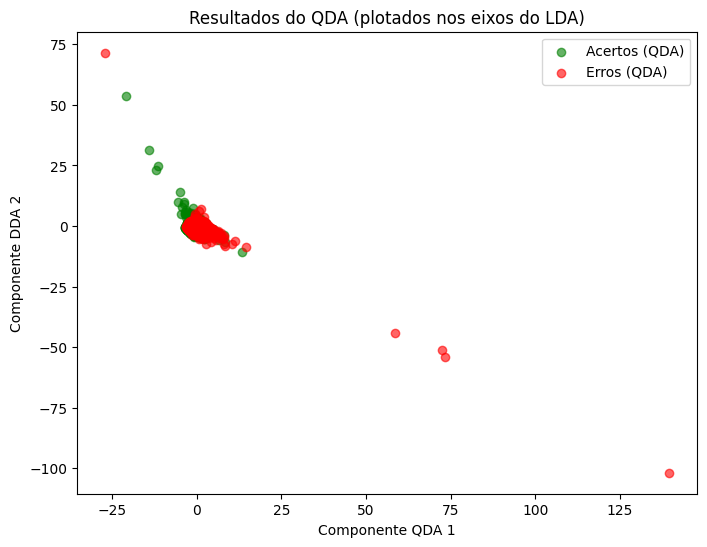

In [13]:

y_pred_qda = qda.predict(X_test)
acertos_qda = (y_pred_qda == y_test)
erros_qda = ~acertos_qda

X_lda_eixos = lda.transform(X_test)

plt.figure(figsize=(8,6))
plt.scatter(X_lda_eixos[acertos_qda, 0], X_lda_eixos[acertos_qda, 1], color='green', label='Acertos (QDA)', alpha=0.6)
plt.scatter(X_lda_eixos[erros_qda, 0], X_lda_eixos[erros_qda, 1], color='red', label='Erros (QDA)', alpha=0.6)
plt.title('Resultados do QDA (plotados nos eixos do LDA)')
plt.xlabel('Componente QDA 1')
plt.ylabel('Componente DDA 2')
plt.legend()
plt.show()

In [14]:
cm = confusion_matrix(y_test, y_pred_qda)

# SVM

`Param_grid` será usado para ambas variações do SVM.

In [15]:
param_grid = {'C': [0.1, 1, 2, 10]}

# SVM (Gaussiano)

Abaixo temos o treinamento do modelo com Kernel gaussiano, antecedido por pelos hiper parâmetros.

In [16]:
grid = GridSearchCV(
    SVC(kernel='rbf', max_iter=1000),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print("Melhor score CV:", grid.best_score_)
print("Melhores parâmetros:", grid.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/home/pedromiguel435/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/pedromiguel435/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/pedromiguel435/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/pedromiguel435/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/pedromiguel435/.local/lib/python3.13/site-packages/sklearn/svm

Melhor score CV: 0.3274665242750349
Melhores parâmetros: {'C': 1}


/home/pedromiguel435/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Aqui temos a medição das acurácias nos dados de treino e nos dados de teste.

In [17]:
best = grid.best_estimator_
y_pred = best.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Train Accuracy:", accuracy_score(y_train, best.predict(X_train)))
print(classification_report(y_test, y_pred))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

Test Accuracy: 0.2688491762492794
Train Accuracy: 0.267312905610778
               precision    recall  f1-score   support

 0 dependents       0.68      0.25      0.37     58618
  1 dependent       0.18      0.30      0.23     17618
2 ddependents       0.16      0.03      0.04     13298
3+ dependents       0.13      0.64      0.22      9343

     accuracy                           0.27     98877
    macro avg       0.29      0.31      0.22     98877
 weighted avg       0.47      0.27      0.29     98877

Confusion matrix:
 [[14878 19781  1216 22743]
 [ 3196  5346   365  8711]
 [ 2155  2404   345  8394]
 [ 1589  1528   212  6014]]


Abaixo temos o treinamento do modelo SVM com Kernel linear, antecedido por pelos hiper parâmetros.

In [18]:
grid = GridSearchCV(
    SVC(kernel='linear', max_iter=1000),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print("Melhor score CV:", grid.best_score_)
print("Melhores parâmetros:", grid.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/home/pedromiguel435/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/pedromiguel435/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/pedromiguel435/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/pedromiguel435/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/pedromiguel435/.local/lib/python3.13/site-packages/sklearn/svm

Melhor score CV: 0.15824639228894546
Melhores parâmetros: {'C': 10}


/home/pedromiguel435/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Aqui temos a medição das acurácias nos dados de treino e nos dados de teste.

In [19]:
best = grid.best_estimator_
y_pred = best.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Train Accuracy:", accuracy_score(y_train, best.predict(X_train)))
print(classification_report(y_test, y_pred))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

Test Accuracy: 0.10432153079078046
Train Accuracy: 0.10139927161203757
               precision    recall  f1-score   support

 0 dependents       0.77      0.01      0.01     58618
  1 dependent       0.21      0.06      0.10     17618
2 ddependents       0.17      0.01      0.02     13298
3+ dependents       0.09      0.93      0.17      9343

     accuracy                           0.10     98877
    macro avg       0.31      0.25      0.08     98877
 weighted avg       0.53      0.10      0.04     98877

Confusion matrix:
 [[  341  3056   444 54777]
 [   61  1134   187 16236]
 [   23   732   157 12386]
 [   18   510   132  8683]]


# Resultados

| Modelo                | Acurácia Treino | Acurácia do Teste |
|-----------------------|-----------------|-------------------|
| LDA                   | 0.5931          | 0.5909            |
| QDA (reg_param = 0.999)| 0.5924          | 0.5904            |
| SVM (linear)           | 0.1013          | 0.1043            |
| SVM (gaussiano)        | 0.2673          | 0.2688            |

Em geral, os modelos baseados em análise discriminante (LDA e QDA) apresentaram desempenho semelhante e superior aos modelos de SVM, atingindo acurácias próximas de 59% tanto no treino quanto no teste, o que indica boa capacidade de generalização.

O QDA, apesar de mais flexível, acabou se comportando de forma muito próxima ao LDA devido à forte regularização aplicada (`reg_param` ≈ 1), que reduz a complexidade do modelo.

Já os modelos SVM (linear e gaussiano) apresentaram desempenho significativamente inferior, sugerindo que o padrão dos dados não é bem capturado pelas fronteiras de decisão impostas por esses kernels, possivelmente por sobreposição entre classes e natureza pouco separável das variáveis explicativas.

Porém, os hiper parâmetros dos modelos SVM podem ser melhor explorados (tais como $\gamma$ do modelo SVM gaussiano). Contudo, já conseguimos bons resultados com LDA e QDA.

Assim, para este conjunto de dados, os classificadores lineares (LDA/QDA) mostraram-se mais adequados.